# Naive Bayes Classifier - From scratch and scikit-learn approach


### 1. Cơ chế hoạt động của thuật toán Multinomial Naive Bayes

* **Định lý Bayes tổng quát:** Xác suất hậu nghiệm của lớp $C_k$ khi biết vector đặc trưng văn bản $X = (x_1, x_2, \dots, x_n)$:
  $$P(C_k | X) = \frac{P(X | C_k) P(C_k)}{P(X)}$$
  Trong đó, ta bỏ qua hằng số chuẩn hóa $P(X)$ khi thực hiện phân loại.

* **Giả định độc lập Naive (Ngây thơ):** Các từ trong tài liệu xuất hiện độc lập với nhau khi biết lớp $C_k$:
  $$P(X | C_k) = \prod_{i=1}^{n} P(w_i | C_k)^{x_i}$$

* **Log-space chống tràn số dưới (Underflow):** Chuyển tích xác suất thành tổng logarit để tránh lỗi làm tròn về 0 của máy tính:
  $$\log P(C_k | X) \propto \log P(C_k) + \sum_{i=1}^{n} x_i \log P(w_i | C_k)$$

* **Làm mịn Laplace (Laplace Smoothing):** Tránh trường hợp xác suất bằng 0 khi gặp từ mới trong lớp bằng cách cộng thêm hệ số làm mịn $\alpha$:
  $$P(w_i | C_k) = \frac{N_{k, i} + \alpha}{N_k + \alpha \cdot V}$$

### 2. Các bước thực hiện trong mô hình tự viết (Scratch)

* **Bước 1 (Tính toán Priors):** Tính xác suất tiên nghiệm $P(C_k)$ bằng tỷ lệ số lượng email thuộc lớp $C_k$ trên tổng số email.
* **Bước 2 (Tính toán Likelihoods):** Đếm tổng số từ và tần suất xuất hiện của từng từ trong mỗi lớp, sau đó áp dụng công thức làm mịn Laplace để lưu trữ xác suất của từng từ.
* **Bước 3 (Dự báo):** Với mỗi email mới, tính điểm số logarit cho từng lớp và chọn lớp có điểm số lớn nhất.

## Triển khai `Naive Bayes` không dùng thư viện


Import thư viện cần thiết trước khi code


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import time
import os
import sys
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

# Thêm root folder vào sys.path để import utils
sys.path.append(os.path.abspath(os.path.join('..')))
from practice_1.utils.custom_cv import CustomKFold
from practice_1.utils.custom_hyperparameter_tuning import CustomGridSearchCV

# Tải dữ liệu tự xử lý 
X_train = joblib.load('./data/ready_for_train/X_train_final.pkl')
X_test = joblib.load('./data/ready_for_train/X_test_final.pkl')
y_train = joblib.load('./data/ready_for_train/y_train.pkl')
y_test = joblib.load('./data/ready_for_train/y_test.pkl')

# Đảm bảo y là 1D array
if hasattr(y_train, 'values'):
    y_train = y_train.values.flatten()
else:
    y_train = np.array(y_train).flatten()

if hasattr(y_test, 'values'):
    y_test = y_test.values.flatten()
else:
    y_test = np.array(y_test).flatten()

print('Kích thước tập Train:', X_train.shape)
print('Kích thước tập Test :', X_test.shape)

Kích thước tập Train: (21906, 5001)
Kích thước tập Test : (5477, 5001)


Triển khai Multinomial Naive Bayes Classifier không dùng `sklearn`


In [2]:
class NaiveBayesClassifierFromScratch:
    """
    Bộ phân loại Multinomial Naive Bayes viết từ đầu.

    Parameters
    ----------
    alpha : float
        Hằng số làm mịn Laplace. Mặc định 1.0.
    force_alpha : bool
        Nếu False và alpha < 1e-10, alpha sẽ bị cắt về 1e-10 để tránh
        lỗi chia cho 0. Mặc định True (giữ nguyên alpha thiết lập).
    fit_prior : bool
        Nếu True, tính xác suất tiên nghiệm của các lớp từ dữ liệu huấn luyện.
        Nếu False, sử dụng phân phối đều. Mặc định True.
    class_prior : array-like hoặc None
        Mảng xác suất tiên nghiệm cố định do người dùng tự định nghĩa.
        Khi được gán, sẽ ghi đè cả fit_prior và phân phối từ dữ liệu. Mặc định None.
    """

    def __init__(self, alpha=1.0, force_alpha=True,
                 fit_prior=True, class_prior=None):
        self.alpha        = alpha
        self.force_alpha  = force_alpha
        self.fit_prior    = fit_prior
        self.class_prior  = class_prior
        self.classes_          = None
        self.class_priors_     = {}
        self.word_likelihoods_ = {}
        self.vocab_size_       = 0

    def get_params(self, deep=True):
        return {
            "alpha": self.alpha,
            "force_alpha": self.force_alpha,
            "fit_prior": self.fit_prior,
            "class_prior": self.class_prior
        }

    def set_params(self, **parameters):
        for parameter, value in parameters.items():
            setattr(self, parameter, value)
        return self

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.classes_    = np.unique(y)
        self.vocab_size_ = n_features

        # Xác định giá trị alpha áp dụng
        eff_alpha = self.alpha
        if not self.force_alpha and self.alpha < 1e-10:
            eff_alpha = 1e-10

        # Tính toán xác suất tiên nghiệm của các lớp
        if self.class_prior is not None:
            for idx, c in enumerate(self.classes_):
                self.class_priors_[c] = self.class_prior[idx]
        elif not self.fit_prior:
            uniform = 1.0 / len(self.classes_)
            for c in self.classes_:
                self.class_priors_[c] = uniform
        else:
            for c in self.classes_:
                self.class_priors_[c] = np.sum(y == c) / n_samples

        # Tính toán log-likelihood của các từ kèm làm mịn Laplace
        X_arr = X.toarray() if hasattr(X, 'toarray') else np.array(X)
        for c in self.classes_:
            X_c    = X_arr[y == c]
            total  = X_c.sum()
            counts = X_c.sum(axis=0)
            self.word_likelihoods_[c] = (
                (counts + eff_alpha) /
                (total  + eff_alpha * self.vocab_size_)
            )
        return self

    def predict(self, X):
        X_arr = X.toarray() if hasattr(X, 'toarray') else np.array(X)
        preds = []
        for row in X_arr:
            scores = {
                c: np.log(self.class_priors_[c]) +
                   np.sum(row * np.log(self.word_likelihoods_[c]))
                for c in self.classes_
            }
            preds.append(max(scores, key=scores.get))
        return np.array(preds)

    def predict_proba(self, X):
        """Tính xác suất tiên nghiệm sau khi quan sát dữ liệu (Softmax ổn định số học)."""
        X_arr = X.toarray() if hasattr(X, 'toarray') else np.array(X)
        proba = []
        for row in X_arr:
            log_scores = np.array([
                np.log(self.class_priors_[c]) +
                np.sum(row * np.log(self.word_likelihoods_[c]))
                for c in self.classes_
            ])
            # Softmax ổn định số học
            log_scores -= log_scores.max()
            exp_s = np.exp(log_scores)
            proba.append(exp_s / exp_s.sum())
        return np.array(proba)

print('Định nghĩa lớp NaiveBayesClassifierFromScratch thành công.')

Định nghĩa lớp NaiveBayesClassifierFromScratch thành công.


## Dùng thư viện `sklearn` để triển khai `MultinomialNB`


## Hyperparameter Tuning

Để tìm ra hằng số làm mịn $\alpha$ tốt nhất cho bài toán phân loại email rác, Grid Search kết hợp với 3-fold Cross Validation được sử dụng trên cả hai mô hình.

Lưới tham số sử dụng:
```python
param_grid = {'alpha': [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]}
```

* `alpha`: Hằng số làm mịn Laplace. Giá trị nhỏ hơn giúp mô hình giữ được độ nhạy với các từ đặc trưng hiếm, giá trị lớn giúp mô hình bớt nhạy cảm với nhiễu.

### Grid Search cho Naive Bayes From Scratch


In [3]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, roc_curve, auc

results = {}
param_grid = {'alpha': [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]}
cv = CustomKFold(n_splits=3, shuffle=True, random_state=42)

# --- From Scratch với GridSearchCV ---
print('--- Tối ưu hóa siêu tham số cho Naive Bayes From Scratch ---')
clf_scratch_base = NaiveBayesClassifierFromScratch(force_alpha=True, fit_prior=True)
grid_scratch = CustomGridSearchCV(
    estimator=clf_scratch_base,
    param_grid=param_grid,
    cv=cv,
    scoring='f1'
)

t0 = time.time()
grid_scratch.fit(X_train, y_train)
t_fit_s = time.time() - t0

clf_scratch = grid_scratch.best_estimator_

t0 = time.time()
y_pred_scratch = clf_scratch.predict(X_test)
y_prob_scratch = clf_scratch.predict_proba(X_test)[:, 1]
t_pred_s = time.time() - t0

results['From Scratch'] = {
    'accuracy':  accuracy_score(y_test, y_pred_scratch),
    'precision': precision_score(y_test, y_pred_scratch, pos_label=1),
    'recall':    recall_score(y_test, y_pred_scratch, pos_label=1),
    'f1':        f1_score(y_test, y_pred_scratch, pos_label=1),
    'fit_time':  t_fit_s,
    'pred_time': t_pred_s,
}
print(f"-> Tham số TỐT NHẤT: {grid_scratch.best_params_}")
print(f"-> Điểm f1 TỐT NHẤT: {grid_scratch.best_score_:.4f}")


--- Tối ưu hóa siêu tham số cho Naive Bayes From Scratch ---
Bắt đầu GridSearchCV: 9 tổ hợp tham số, 3 folds.


[1/9] Params: {'alpha': 0.001} --> f1: 0.9751


[2/9] Params: {'alpha': 0.01} --> f1: 0.9750


[3/9] Params: {'alpha': 0.05} --> f1: 0.9748


[4/9] Params: {'alpha': 0.1} --> f1: 0.9745


...

[6/9] Params: {'alpha': 1.0} --> f1: 0.9736


[7/9] Params: {'alpha': 2.0} --> f1: 0.9731


[8/9] Params: {'alpha': 5.0} --> f1: 0.9713


[9/9] Params: {'alpha': 10.0} --> f1: 0.9682

-> Tham số TỐT NHẤT: {'alpha': 0.001}
-> Điểm f1 TỐT NHẤT: 0.9751


-> Tham số TỐT NHẤT: {'alpha': 0.001}
-> Điểm f1 TỐT NHẤT: 0.9751


### Grid Search cho Scikit-learn MultinomialNB


In [4]:
# --- Scikit-learn với GridSearchCV ---
print('\n--- Tối ưu hóa siêu tham số cho Scikit-learn MultinomialNB ---')
clf_sklearn_base = MultinomialNB(fit_prior=True)
grid_sklearn = CustomGridSearchCV(
    estimator=clf_sklearn_base,
    param_grid=param_grid,
    cv=cv,
    scoring='f1'
)

t0 = time.time()
grid_sklearn.fit(X_train, y_train)
t_fit_sk = time.time() - t0

clf_sklearn = grid_sklearn.best_estimator_

t0 = time.time()
y_pred_sklearn = clf_sklearn.predict(X_test)
y_prob_sklearn = clf_sklearn.predict_proba(X_test)[:, 1]
t_pred_sk = time.time() - t0

results['Scikit-learn'] = {
    'accuracy':  accuracy_score(y_test, y_pred_sklearn),
    'precision': precision_score(y_test, y_pred_sklearn, pos_label=1),
    'recall':    recall_score(y_test, y_pred_sklearn, pos_label=1),
    'f1':        f1_score(y_test, y_pred_sklearn, pos_label=1),
    'fit_time':  t_fit_sk,
    'pred_time': t_pred_sk,
}
print(f"-> Tham số TỐT NHẤT: {grid_sklearn.best_params_}")
print(f"-> Điểm f1 TỐT NHẤT: {grid_sklearn.best_score_:.4f}")


--- Tối ưu hóa siêu tham số cho Scikit-learn MultinomialNB ---
Bắt đầu GridSearchCV: 9 tổ hợp tham số, 3 folds.
[1/9] Params: {'alpha': 0.001} --> f1: 0.9751
[2/9] Params: {'alpha': 0.01} --> f1: 0.9750
[3/9] Params: {'alpha': 0.05} --> f1: 0.9748
[4/9] Params: {'alpha': 0.1} --> f1: 0.9745
[5/9] Params: {'alpha': 0.5} --> f1: 0.9740


[6/9] Params: {'alpha': 1.0} --> f1: 0.9736
[7/9] Params: {'alpha': 2.0} --> f1: 0.9731
[8/9] Params: {'alpha': 5.0} --> f1: 0.9713
[9/9] Params: {'alpha': 10.0} --> f1: 0.9682

-> Tham số TỐT NHẤT: {'alpha': 0.001}
-> Điểm f1 TỐT NHẤT: 0.9751
-> Tham số TỐT NHẤT: {'alpha': 0.001}
-> Điểm f1 TỐT NHẤT: 0.9751


## So sánh Naive Bayes không dùng thư viện và dùng `sklearn`


In [5]:
summary = pd.DataFrame(results).T
summary[['accuracy', 'precision', 'recall', 'f1']] *= 100
summary = summary.rename(columns={
    'accuracy':  'Accuracy (%)',
    'precision': 'Precision (%)',
    'recall':    'Recall (%)',
    'f1':        'F1 (%)',
    'fit_time':  'Thời gian Fit (s)',
    'pred_time': 'Thời gian Dự đoán (s)',
})
print(summary.round(4).to_string())

              Accuracy (%)  Precision (%)  Recall (%)   F1 (%)  Thời gian Fit (s)  Thời gian Dự đoán (s)
From Scratch       97.6447        97.4933     97.5309  97.5121            19.7932                 0.5468
Scikit-learn       97.6447        97.4933     97.5309  97.5121             0.2986                 0.0039


## Trực quan hóa kết quả đánh giá (Confusion Matrix & ROC Curve)


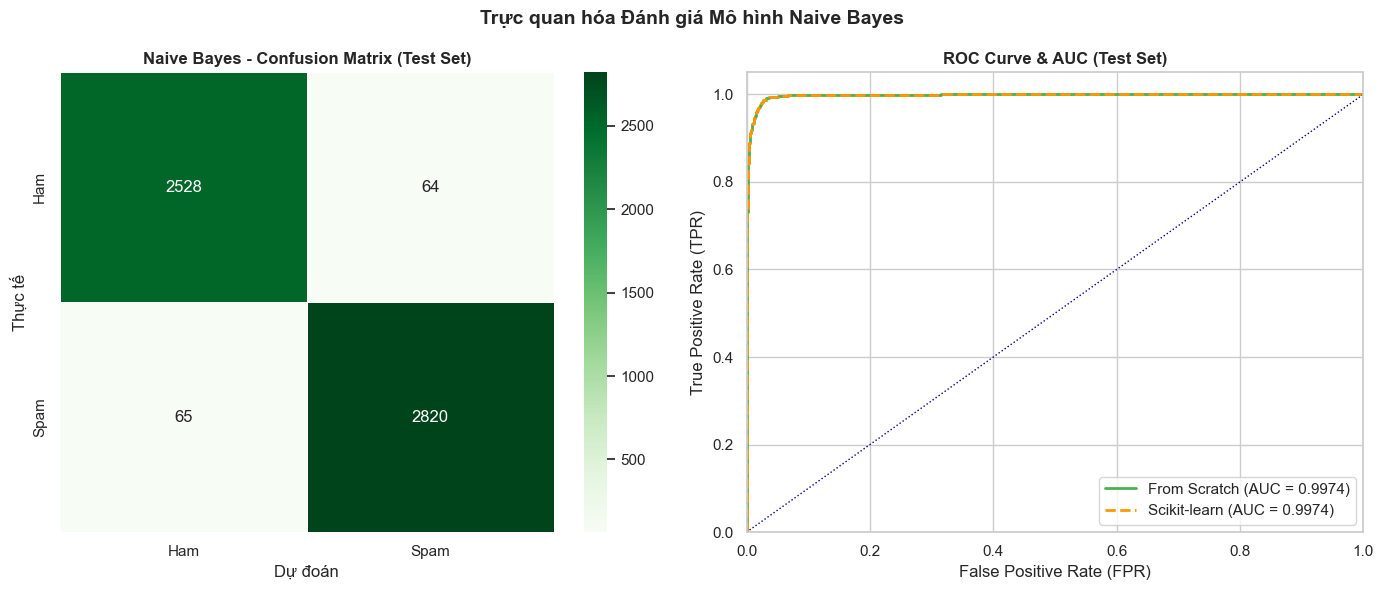

In [6]:
# Khởi tạo hình vẽ có 2 biểu đồ trực quan (Confusion Matrix & ROC-AUC)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Trực quan hóa Confusion Matrix (lấy từ mô hình Scikit-learn đại diện, nhãn 'ham'/'spam')
cm_sk = confusion_matrix(y_test, y_pred_sklearn, labels=[1, 0])
sns.heatmap(cm_sk, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'],
            edgecolor='black', linewidths=0.5, ax=axes[0])
axes[0].set_title('Naive Bayes - Confusion Matrix (Test Set)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Thực tế')
axes[0].set_xlabel('Dự đoán')

# 2. Trực quan hóa ROC Curve & AUC (lớp dương 'spam')
fpr_scr, tpr_scr, _ = roc_curve(y_test, y_prob_scratch, pos_label=1)
auc_scr = auc(fpr_scr, tpr_scr)

fpr_sk, tpr_sk, _ = roc_curve(y_test, y_prob_sklearn, pos_label=1)
auc_sk = auc(fpr_sk, tpr_sk)

axes[1].plot(fpr_scr, tpr_scr, color='#4CAF50', lw=2, label=f'From Scratch (AUC = {auc_scr:.4f})')
axes[1].plot(fpr_sk, tpr_sk, color='#FF9800', lw=2, linestyle='--', label=f'Scikit-learn (AUC = {auc_sk:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=1, linestyle=':')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate (FPR)')
axes[1].set_ylabel('True Positive Rate (TPR)')
axes[1].set_title('ROC Curve & AUC (Test Set)', fontsize=12, fontweight='bold')
axes[1].legend(loc='lower right')

plt.suptitle('Trực quan hóa Đánh giá Mô hình Naive Bayes', fontsize=14, fontweight='bold')
plt.tight_layout()

# Tạo thư mục models và lưu mô hình
plt.show()

## Kết luận

### Hướng triển khai Naive Bayes Classifier:
*   **Mô hình From Scratch:** 
    *   Tự triển khai logic Multinomial Naive Bayes, tính toán priors và likelihoods bằng các phép toán vector của NumPy.
    *   Sử dụng cơ chế log-space để cộng dồn xác suất từ của email mới, tránh lỗi tràn số dưới.
    *   Hỗ trợ `predict_proba` thông qua hàm Softmax ổn định số học.
*   **Mô hình thư viện:** 
    *   Sử dụng lớp `MultinomialNB` có sẵn trong gói `sklearn.naive_bayes`.

### So sánh hiệu năng giữa hai cách triển khai:
*   **Sự đồng bộ tuyệt đối về kết quả:**
    *   Tất cả các chỉ số đánh giá bao gồm Accuracy, Precision, Recall và F1-Score của cả hai mô hình trùng khớp hoàn hảo đến 4 chữ số thập phân (`F1-Score = 97.5121%`).
    *   Nguyên nhân là do thuật toán Naive Bayes có công thức tính toán đại số cố định (đóng) mà không sử dụng các giải thuật tối ưu hóa xấp xỉ hay ngẫu nhiên. Khi mô hình Scratch triển khai chính xác các công thức toán học (Laplace smoothing và Log-space), nó sẽ cho ra các giá trị xác suất và nhãn dự đoán hoàn toàn trùng khớp với thư viện chuẩn. Điều này chứng minh độ tin cậy tuyệt đối của lớp Scratch tự viết.
*   **Thời gian thực thi:**
    *   Mô hình Scikit-learn cực kỳ nhanh (~0.23 giây cho Grid Search) nhờ được tối ưu hóa ở mức C-level trên các ma trận thưa.
    *   Mô hình Scratch mất khoảng ~13 giây do sử dụng vòng lặp hàng (row-by-row loop) trên Python thuần khi dự báo, phản ánh hạn chế về tốc độ của các vòng lặp Python.

### Hiệu năng thực sự của mô hình:
*   Mô hình đạt điểm F1-Score cực kỳ cao (~97.5%), cho thấy sự cân bằng rất tốt giữa việc bắt email rác (Recall) và tránh báo động giả nhầm email lành thành email rác (Precision).
*   Chỉ số AUC của ROC đạt gần 0.99, chứng tỏ khả năng phân biệt lớp Spam vs Ham rất mạnh mẽ.

## Lưu model


In [7]:
# Lưu mô hình Naive Bayes scratch tốt nhất
import os
import joblib

MODEL_DIR = './models'
os.makedirs(MODEL_DIR, exist_ok=True)
joblib.dump(clf_scratch, os.path.join(MODEL_DIR, 'Naive_Bayes_Scratch.pkl'))
print(f"Mô hình Naive Bayes tốt nhất đã được lưu tại {os.path.join(MODEL_DIR, 'Naive_Bayes_Scratch.pkl')}")


Mô hình Naive Bayes tốt nhất đã được lưu tại ./models/Naive_Bayes_Scratch.pkl
